# 🏨 Hotel Booking Cancellation Predictor

## Deep Learning Classification with Keras

This notebook develops an Artificial Neural Network (ANN) to predict whether a hotel booking will be **cancelled (`1`) or not cancelled (`0`)**.

The workflow follows an end-to-end machine learning process:

**Data Loading → Exploratory Data Analysis → Data Cleaning → Feature Engineering → Encoding → Train/Test Split → Scaling → ANN Training → Regularization → Evaluation → Prediction**

The main purpose of this project is to practice the complete Keras workflow on a real-world binary classification problem while understanding how booking characteristics relate to cancellation behavior.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [7]:
import pandas as pd
import numpy as np
from tensorflow import keras


## 1. Data Loading

The hotel booking dataset is loaded into a Pandas DataFrame. Before modeling, the dataset structure, feature types, missing values, duplicates, and target distribution are explored.


In [8]:
df = pd.read_csv("hotel_bookings.csv")

## 2. Exploratory Data Analysis (EDA)

EDA is used to understand the dataset before preprocessing or training the neural network. The analysis focuses especially on variables that may be associated with the target variable, `is_canceled`.

### 2.1 Dataset Structure and Data Quality

The following cells inspect dataset dimensions, sample records, data types, descriptive statistics, missing values, and duplicate records.


In [9]:
df.shape

(119390, 32)

In [10]:
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [12]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [13]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [14]:
 missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
company,112593
agent,16340
country,488
children,4


In [15]:
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct[missing_pct > 0]

,0
company,94.306893
agent,13.686238
country,0.408744
children,0.003350


In [16]:
df.duplicated().sum()

np.int64(31994)

### 2.2 Target Variable — Booking Cancellation

`is_canceled` is the target variable:

- **0** → Booking was not cancelled
- **1** → Booking was cancelled

The class distribution is examined to understand how common cancellations are in the dataset.


In [22]:
df["is_canceled"].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,62.958372
1,37.041628


### 2.3 Hotel Type and Cancellation

The dataset contains different hotel types. Comparing their cancellation rates helps determine whether hotel type may carry predictive information.


In [23]:
df["hotel"].value_counts()

,count
hotel,
City Hotel,79330
Resort Hotel,40060


In [24]:
df.groupby("hotel")["is_canceled"].mean()

,is_canceled
hotel,
City Hotel,0.417270
Resort Hotel,0.277634


### 2.4 Lead Time Analysis

`lead_time` represents the number of days between booking creation and arrival. Its distribution and average values are compared between cancelled and non-cancelled bookings to investigate whether bookings made further in advance behave differently.


NameError: name 'plt' is not defined

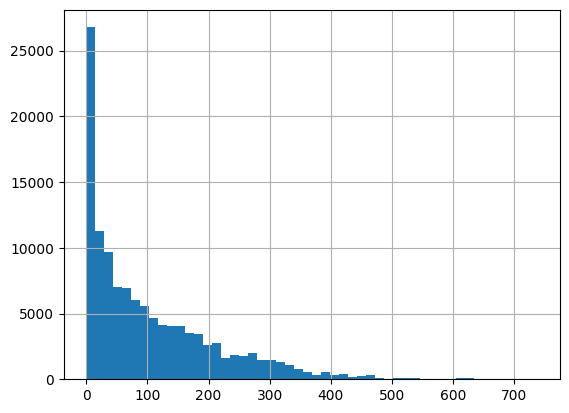

In [26]:
df["lead_time"].hist(bins=50)
plt.xlabel("Lead Time")
plt.ylabel("Frequency")
plt.show()

In [27]:
df.groupby("is_canceled")["lead_time"].mean()

,lead_time
is_canceled,
0,79.984687
1,144.848815


### 2.5 Average Daily Rate (ADR)

`adr` represents the Average Daily Rate. Comparing ADR across cancellation classes helps explore whether booking price is associated with cancellation behavior.


In [29]:
df.groupby("is_canceled")["adr"].mean()

,adr
is_canceled,
0,99.987693
1,104.964333


### 2.6 Arrival Month and Seasonality

Arrival month is examined to identify seasonal patterns in booking volume and cancellation rates.


In [30]:
df["arrival_date_month"].value_counts()

,count
arrival_date_month,
August,13877
July,12661
May,11791
October,11160
April,11089
June,10939
September,10508
March,9794
February,8068


In [31]:
df.groupby(
    "arrival_date_month"
)["is_canceled"].mean()

,is_canceled
arrival_date_month,
April,0.407972
August,0.377531
December,0.349705
February,0.334160
January,0.304773
July,0.374536
June,0.414572
March,0.321523
May,0.396658


### 2.7 Market Segment

Bookings originate through different market segments. Their frequency and cancellation rates are compared to identify differences in customer acquisition channels.


In [32]:
df["market_segment"].value_counts()

,count
market_segment,
Online TA,56477
Offline TA/TO,24219
Groups,19811
Direct,12606
Corporate,5295
Complementary,743
Aviation,237
Undefined,2


In [33]:
df.groupby(
    "market_segment"
)["is_canceled"].mean().sort_values(ascending=False)

,is_canceled
market_segment,
Undefined,1.000000
Groups,0.610620
Online TA,0.367211
Offline TA/TO,0.343160
Aviation,0.219409
Corporate,0.187347
Direct,0.153419
Complementary,0.130552


### 2.8 Distribution Channel

Distribution channels describe how bookings reach the hotel. This analysis explores the composition of those channels before modeling.


In [34]:
df["distribution_channel"].value_counts()

,count
distribution_channel,
TA/TO,97870
Direct,14645
Corporate,6677
GDS,193
Undefined,5


### 2.9 Deposit Type

Deposit policy may be strongly related to cancellation behavior. A normalized cross-tabulation and cancellation-rate comparison are used to examine the relationship between deposit type and the target.


In [35]:
pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
deposit_type,,
No Deposit,0.716230,0.283770
Non Refund,0.006376,0.993624
Refundable,0.777778,0.222222


In [36]:
df.groupby(
    "deposit_type"
)["is_canceled"].mean().sort_values(ascending=False)

,is_canceled
deposit_type,
Non Refund,0.993624
No Deposit,0.283770
Refundable,0.222222


### 2.10 Customer Type

Different customer categories may exhibit different booking behavior. Cancellation rates are therefore compared across customer types.


In [38]:
df["customer_type"].value_counts()

,count
customer_type,
Transient,89613
Transient-Party,25124
Contract,4076
Group,577


In [39]:
df.groupby(
    "customer_type"
)["is_canceled"].mean().sort_values(ascending=False)

,is_canceled
customer_type,
Transient,0.407463
Contract,0.309617
Transient-Party,0.254299
Group,0.102253


### 2.11 Repeated Guests

This analysis checks whether guests who have booked previously show different cancellation behavior from first-time guests.


In [41]:
df.groupby(
    "is_repeated_guest"
)["is_canceled"].mean()

,is_canceled
is_repeated_guest,
0,0.377851
1,0.144882


### 2.12 Special Requests and Booking Changes

The relationship between cancellation and customer engagement is explored using the number of special requests and booking changes.


In [43]:
df.groupby(
    "total_of_special_requests"
)["is_canceled"].mean()

,is_canceled
total_of_special_requests,
0,0.477204
1,0.220249
2,0.220989
3,0.178614
4,0.105882
5,0.050000


In [44]:
df.groupby(
    "booking_changes"
)["is_canceled"].mean().head(10)

,is_canceled
booking_changes,
0,0.408542
1,0.142272
2,0.201314
3,0.155340
4,0.178191
5,0.169492
6,0.285714
7,0.096774
8,0.235294


### 2.13 Guest Composition

A new `total_guests` variable is temporarily created during EDA by combining adults, children, and babies. This helps identify unusual records such as bookings containing zero guests and explore cancellation behavior by party size.


In [45]:
df["total_guests"] = (
    df["adults"]
    + df["children"].fillna(0)
    + df["babies"]
)

In [46]:
(df["total_guests"] == 0).sum()


np.int64(180)

In [47]:
df.groupby(
    "total_guests"
)["is_canceled"].mean().head(10)

,is_canceled
total_guests,
0.0,0.138889
1.0,0.290288
2.0,0.396973
3.0,0.321772
4.0,0.418936
5.0,0.248175
6.0,1.000000
10.0,0.500000
12.0,0.500000


### 2.14 Country Analysis

The most common guest countries are examined. Cancellation rates are also calculated for countries with sufficient booking volume so that very small groups do not dominate the comparison.


In [48]:
df["country"].value_counts().head(10)

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
ITA,3766
IRL,3375
BEL,2342
BRA,2224


In [51]:
country_stats = df.groupby("country").agg(
    bookings=("is_canceled", "count"),
    cancellation_rate=("is_canceled", "mean")
)

country_stats[
    country_stats["bookings"] >= 100
].sort_values(
    "cancellation_rate",
    ascending=False
).head(10)

,bookings,cancellation_rate
country,,
PRT,48590,0.566351
AGO,362,0.566298
CHN,999,0.462462
MAR,259,0.420849
KOR,133,0.413534
TUR,248,0.411290
LUX,287,0.379791
RUS,632,0.378165
BRA,2224,0.373201


### 2.15 Numerical Correlation Analysis

Numerical correlations provide a quick overview of linear relationships between numeric features and `is_canceled`. Correlation does not establish causation, but it can highlight variables worth investigating further.


In [52]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

In [53]:
numeric_df.corr()["is_canceled"].sort_values(
    ascending=False
)

,is_canceled
is_canceled,1.000000
lead_time,0.293123
previous_cancellations,0.110133
adults,0.060017
days_in_waiting_list,0.054186
adr,0.047557
total_guests,0.046522
stays_in_week_nights,0.024765
arrival_date_year,0.016660
arrival_date_week_number,0.008148


In [55]:
import matplotlib.pyplot as plt


In [57]:
corr = numeric_df.corr()

corr

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests
is_canceled,1.000000,0.293123,0.016660,0.008148,-0.006130,-0.001791,0.024765,0.060017,0.005048,-0.032491,...,0.110133,-0.057358,-0.144381,-0.083114,-0.020642,0.054186,0.047557,-0.195498,-0.234658,0.046522
lead_time,0.293123,1.000000,0.040142,0.126871,0.002268,0.085671,0.165799,0.119519,-0.037622,-0.020915,...,0.086042,-0.073548,0.000149,-0.069741,0.151464,0.170084,-0.063077,-0.116451,-0.095712,0.072265
arrival_date_year,0.016660,0.040142,1.000000,-0.540561,-0.000221,0.021497,0.030883,0.029635,0.054624,-0.013192,...,-0.119822,0.029218,0.030872,0.063457,0.259095,-0.056497,0.197580,-0.013684,0.108531,0.052127
arrival_date_week_number,0.008148,0.126871,-0.540561,1.000000,0.066809,0.018208,0.015558,0.025909,0.005518,0.010395,...,0.035501,-0.020904,0.005508,-0.031201,-0.076760,0.022933,0.075791,0.001920,0.026149,0.025220
arrival_date_day_of_month,-0.006130,0.002268,-0.000221,0.066809,1.000000,-0.016354,-0.028174,-0.001566,0.014544,-0.000230,...,-0.027011,-0.000300,0.010613,0.001487,0.044858,0.022728,0.030245,0.008683,0.003062,0.006742
stays_in_weekend_nights,-0.001791,0.085671,0.021497,0.018208,-0.016354,1.000000,0.498969,0.091871,0.045793,0.018483,...,-0.012775,-0.042715,0.063281,0.140739,0.066749,-0.054151,0.049342,-0.018554,0.072671,0.101426
stays_in_week_nights,0.024765,0.165799,0.030883,0.015558,-0.028174,0.498969,1.000000,0.092976,0.044203,0.020191,...,-0.013992,-0.048743,0.096209,0.182382,0.182211,-0.002020,0.065237,-0.024859,0.068192,0.101665
adults,0.060017,0.119519,0.029635,0.025909,-0.001566,0.091871,0.092976,1.000000,0.030447,0.018146,...,-0.006738,-0.107983,-0.051673,-0.035594,0.207793,-0.008283,0.230641,0.014785,0.122884,0.821105
children,0.005048,-0.037622,0.054624,0.005518,0.014544,0.045793,0.044203,0.030447,1.000000,0.024030,...,-0.024730,-0.021072,0.048949,0.041066,0.030931,-0.033273,0.324854,0.056253,0.081745,0.579373
babies,-0.032491,-0.020915,-0.013192,0.010395,-0.000230,0.018483,0.020191,0.018146,0.024030,1.000000,...,-0.007501,-0.006550,0.083440,0.036184,0.019206,-0.010621,0.029186,0.037383,0.097889,0.162688


### 2.16 Correlation Heatmap

The heatmap provides a visual overview of relationships among numerical variables. Strongly related predictors may contain overlapping information, while correlations with the target can indicate potentially useful predictive signals.


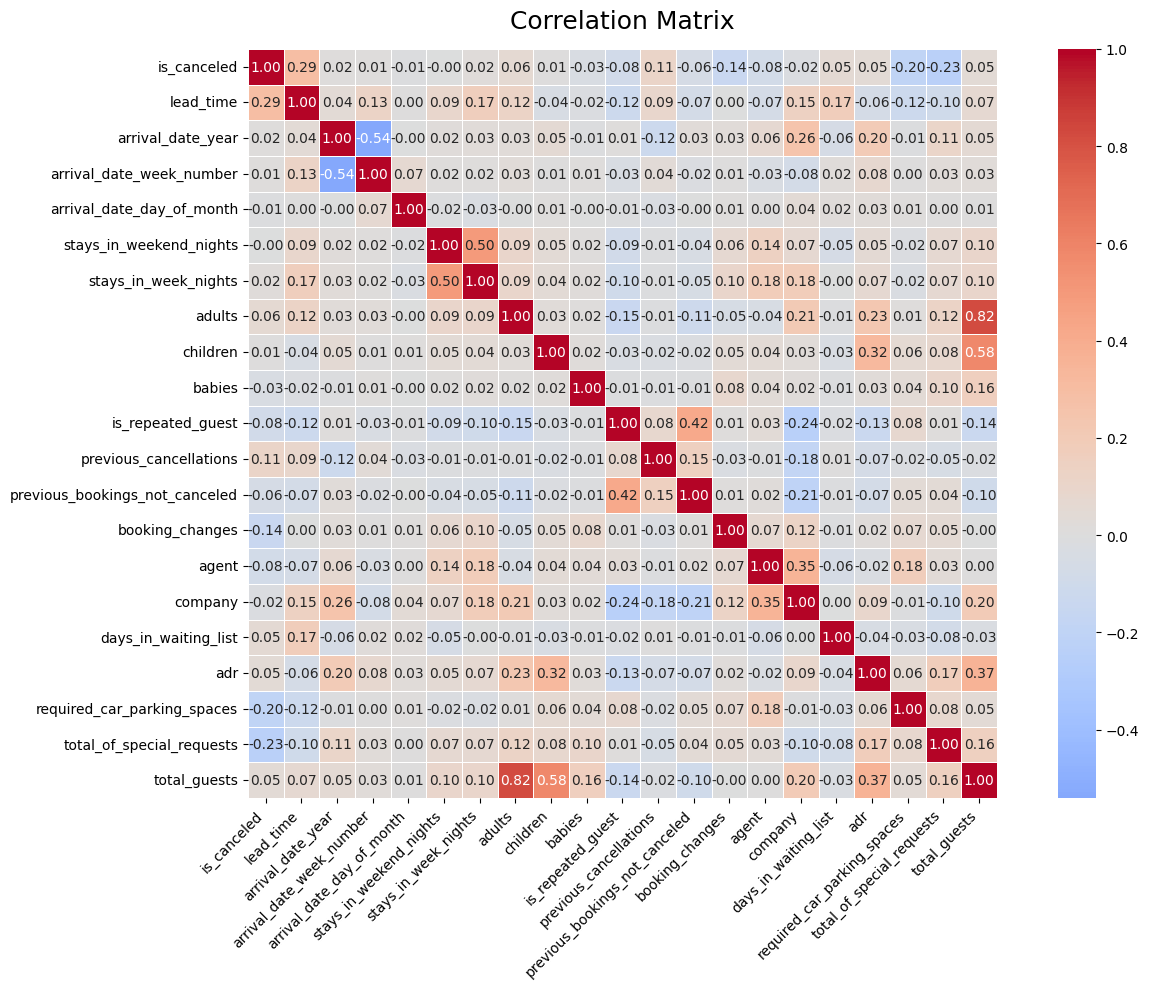

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,          # Show correlation values
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # Color scheme
    center=0,             # 0 = neutral point
    linewidths=0.5,      # Lines between cells
    square=True
)

plt.title("Correlation Matrix", fontsize=18, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 2.17 Categorical Feature Review

Categorical columns and their cardinality are inspected before encoding. This is important because high-cardinality features can create many additional columns during one-hot encoding.


In [60]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

categorical_cols

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [61]:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

hotel : 2
arrival_date_month : 12
meal : 5
country : 177
market_segment : 8
distribution_channel : 5
reserved_room_type : 10
assigned_room_type : 12
deposit_type : 3
customer_type : 4
reservation_status : 3
reservation_status_date : 926


## 3. Data Leakage Check

A critical step before model training is checking whether any feature reveals information that would only be known **after the booking outcome**.

`reservation_status` and `reservation_status_date` are inspected against `is_canceled`. If these variables encode the final booking outcome, including them would allow the model to indirectly see the answer and would produce misleading performance.

For this reason, these outcome-related variables are removed before training.


### Data Leakage Problem

In [62]:
df[
    [
        "is_canceled",
        "reservation_status",
        "reservation_status_date"
    ]
].head(20)

,is_canceled,reservation_status,reservation_status_date
0,0,Check-Out,2015-07-01
1,0,Check-Out,2015-07-01
2,0,Check-Out,2015-07-02
3,0,Check-Out,2015-07-02
4,0,Check-Out,2015-07-03
5,0,Check-Out,2015-07-03
6,0,Check-Out,2015-07-03
7,0,Check-Out,2015-07-03
8,1,Canceled,2015-05-06
9,1,Canceled,2015-04-22


In [63]:
pd.crosstab(
    df["reservation_status"],
    df["is_canceled"]
)

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


In [64]:
df = df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ]
)

## 4. Data Cleaning and Missing Values

After leakage removal, missing values are handled so that the final feature matrix can be processed by the neural network.

The following cells apply the cleaning decisions used in this notebook and then verify that missing values have been resolved.


In [65]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_year,0
hotel,0
arrival_date_day_of_month,0
arrival_date_week_number,0
stays_in_week_nights,0


In [74]:
df["agent"] = df["agent"].fillna(0)

In [75]:
df["agent"] = df["agent"].astype(str)

In [76]:
df = df.drop(columns=["company"])

In [77]:
df["country"] = df["country"].fillna("Unknown")

In [78]:
df["children"] = df["children"].fillna(0)

In [80]:
df.isnull().sum().sum()

np.int64(0)

## 5. Feature Engineering

New variables are created from existing booking information to provide the model with more compact and potentially informative representations.

- **`total_stay`** combines weekday and weekend nights.
- **`total_guests`** combines adults, children, and babies.
- **`room_changed`** indicates whether the assigned room type differs from the reserved room type.

Bookings containing zero total guests are removed, and component columns are then removed where their information has been consolidated into engineered features.


####Feature Engineering

In [81]:
df["total_stay"] = (
    df["stays_in_weekend_nights"]
    + df["stays_in_week_nights"]
)

In [82]:
df["total_guests"] = (
    df["adults"]
    + df["children"]
    + df["babies"]
)

In [83]:
df["room_changed"] = (
    df["reserved_room_type"]
    != df["assigned_room_type"]
).astype(int)

In [84]:
df = df[df["total_guests"] > 0]

In [85]:
df.shape

(119210, 32)

In [86]:
df = df.drop(
    columns=[
        "stays_in_weekend_nights",
        "stays_in_week_nights"
    ]
)

In [87]:
df = df.drop(
    columns=[
        "adults",
        "children",
        "babies"
    ]
)

## 6. Target and Features

The dataset is separated into:

- **`X`** — predictor variables used as ANN inputs
- **`y`** — `is_canceled`, the binary target variable

This separation prepares the data for encoding, splitting, scaling, and model training.


###Target and Features

In [89]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

In [91]:
X.shape

(119210, 26)

In [92]:
y.shape

(119210,)

## 7. Categorical Encoding

Neural networks require numerical inputs. Categorical variables are therefore transformed using **one-hot encoding** with `pd.get_dummies()`.

`drop_first=True` removes one reference category from each encoded categorical feature.


#### Categorical Encoding

In [94]:
categorical_cols = X.select_dtypes(
    include="object"
).columns

categorical_cols

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'agent', 'customer_type'],
      dtype='object')

In [95]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

## 8. Train/Test Split

The dataset is divided into training and testing sets.

- **Training set** → used to learn model parameters.
- **Test set** → kept unseen during training and used for final evaluation.
- **`stratify=y`** → preserves approximately the same cancellation-class distribution in both sets.

A fixed `random_state` makes the split reproducible.


In [98]:
from sklearn.model_selection import train_test_split



In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
print(X_train.shape)
print(X_test.shape)

(95368, 575)
(23842, 575)


## 9. Feature Scaling

`StandardScaler` standardizes the input features before ANN training.

The scaler is **fitted only on the training data** and then applied to both training and test data. This prevents information from the test set from influencing the scaling parameters.


### Scaling

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 10. Artificial Neural Network with Keras

The processed data is now used to train a feed-forward Artificial Neural Network for binary classification.

The model uses:

- **Dense hidden layers** to learn nonlinear relationships.
- **ReLU** activation in hidden layers.
- **Sigmoid** activation in the output layer to produce a cancellation probability between 0 and 1.
- **L2 regularization** to penalize excessively large weights and reduce overfitting.
- **Binary cross-entropy** as the loss function.
- **Adam** as the optimizer.


## Keras ANN

In [102]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 10.1 Input Dimension

After one-hot encoding, the number of ANN inputs is determined dynamically using `X_train.shape[1]`. This ensures that the input layer matches the final number of processed features.


In [103]:
X_train.shape[1]

575

In [105]:
input_shape=(X_train.shape[1])

### 10.2 Model Architecture and Regularization

The ANN contains two hidden Dense layers followed by a single sigmoid output neuron.

L2 regularization (`0.001`) is applied to the hidden layers. Rather than simply minimizing prediction error, L2 also discourages very large model weights, helping control model complexity.


In [152]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dense(1, activation="sigmoid")
])

### 10.3 Model Summary

`model.summary()` displays the network architecture, output shapes, and trainable parameter counts. It is useful for verifying that the model has been constructed as intended.


In [153]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,977 (152.25 KB)

 Trainable params: 38,977 (152.25 KB)

 Non-trainable params: 0 (0.00 B)

### 10.4 Model Compilation

The model is configured for binary classification:

- **Optimizer:** Adam
- **Loss:** Binary Cross-Entropy
- **Metric:** Accuracy

Compilation defines how the ANN measures error and updates its weights during training.


In [154]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### 10.5 Training with Early Stopping

The ANN is allowed to train for up to 100 epochs, but **EarlyStopping** monitors validation loss.

If validation loss does not improve for five consecutive epochs, training stops and `restore_best_weights=True` restores the weights from the best validation-loss epoch. This helps prevent unnecessary training once generalization stops improving.


In [155]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8309 - loss: 0.4201 - val_accuracy: 0.8539 - val_loss: 0.3672
Epoch 2/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8573 - loss: 0.3501 - val_accuracy: 0.8559 - val_loss: 0.3476
Epoch 3/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8621 - loss: 0.3331 - val_accuracy: 0.8621 - val_loss: 0.3354
Epoch 4/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8637 - loss: 0.3254 - val_accuracy: 0.8571 - val_loss: 0.3372
Epoch 5/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8649 - loss: 0.3207 - val_accuracy: 0.8627 - val_loss: 0.3300
Epoch 6/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8680 - loss: 0.3164 - val_accuracy: 0.8617 - val_loss: 0.3294
Epoch 7/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8675 - loss: 0.3131 - val_accuracy: 0.8621 - val_loss: 0.3224
Epoch 8/100
1193/1193 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8692 - loss: 0

### 10.6 Learning Curves

Training and validation loss are plotted across epochs.

These curves are important for diagnosing model behavior:

- Both losses decreasing → the model is learning.
- Training loss decreasing while validation loss rises → possible overfitting.
- Both losses remaining high → possible underfitting.

The objective is not simply to minimize training loss, but to obtain good performance on unseen data.


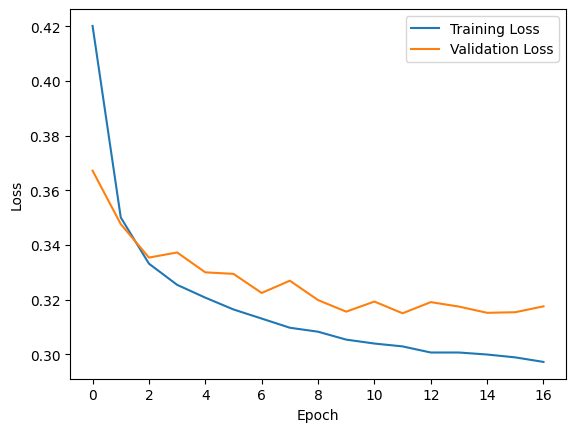

In [156]:
import matplotlib.pyplot as plt

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 11. Model Evaluation

The trained ANN is evaluated using several classification metrics rather than accuracy alone:

- **Accuracy** — overall proportion of correct predictions.
- **Precision** — among bookings predicted as cancelled, how many actually cancelled.
- **Recall** — among actual cancellations, how many the model successfully identified.
- **F1-score** — harmonic balance between precision and recall.
- **ROC-AUC** — measures how well the model separates cancelled from non-cancelled bookings across classification thresholds.

Using multiple metrics gives a more complete picture of model performance.


In [157]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

746/746 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8673768979112491
Precision: 0.8449574726609963
Recall   : 0.7866515837104072
F1 Score : 0.8147627416520211
ROC-AUC  : 0.9419080887254248


# 12. Testing and Prediction

The final model is now applied to the unseen test set.

The sigmoid output is a **probability**, not directly a class label. A threshold of `0.5` is used:

- Probability **< 0.5** → predict **Not Cancelled (0)**
- Probability **≥ 0.5** → predict **Cancelled (1)**

The predicted classes can then be compared with the actual test labels.


### Testing

In [158]:
y_prob = model.predict(X_test)

y_prob[:10]

746/746 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[7.19346479e-02],
       [2.95767672e-02],
       [7.98913762e-02],
       [4.06340368e-05],
       [1.01738684e-01],
       [3.61025073e-02],
       [9.68782961e-01],
       [9.99422133e-01],
       [1.56087488e-01],
       [5.97043395e-01]], dtype=float32)

In [159]:
y_pred = (y_prob >= 0.5).astype(int)

In [160]:
y_pred[:10]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1]])

### 12.1 Actual vs Predicted Results

A results table combines the true target, predicted cancellation probability, and final predicted class. This makes individual predictions easier to inspect and helps identify correct predictions, false positives, and false negatives.


In [161]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_prob.flatten(),
    "Predicted": y_pred.flatten()
})

results.head(20)

,Actual,Probability,Predicted
0,0,0.071935,0
1,0,0.029577,0
2,0,0.079891,0
3,0,0.000041,0
4,0,0.101739,0
5,0,0.036103,0
6,1,0.968783,1
7,1,0.999422,1
8,0,0.156087,0
9,1,0.597043,1


# 13. Manual Prediction

This final section is reserved for testing the trained ANN on an individual booking.

Any new booking must undergo the **same preprocessing used during training**—including categorical encoding structure and scaling—before it is passed to `model.predict()`.

---

## Project Summary

This notebook demonstrates a complete first deep-learning classification workflow using Keras:

**EDA → Data Quality Checks → Leakage Removal → Cleaning → Feature Engineering → Encoding → Train/Test Split → Scaling → ANN → L2 Regularization → Early Stopping → Evaluation → Prediction**

The project emphasizes not only building a neural network, but also preparing the data correctly, avoiding leakage, monitoring generalization, and evaluating predictions using appropriate classification metrics.


### manually predict